<!--Copyright 2026 The HuggingFace Team. All rights reserved.

Licensed under the Apache License, Version 2.0 (the "License"); you may not use this file except in compliance with the License. You may obtain a copy of the License at

http://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software distributed under the License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the specific language governing permissions and limitations under the License.
-->

# Fine-tuning LFM2-VL-450M on a tiny dataset (with loss & before/after visualization)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/huggingface/notebooks/blob/main/examples/lfm2_vl_finetuning.ipynb)

[LFM2-VL-450M](https://huggingface.co/LiquidAI/LFM2-VL-450M) is the smallest of Liquid AI's first vision-language foundation models. It pairs a **350M LFM2** language backbone with an **86M SigLIP2 NaFlex** vision encoder and a pixel-unshuffle MLP connector. At ~450M parameters it is light enough to run in a web browser (WebGPU) — and small enough to **LoRA fine-tune on a single small GPU (or even CPU) with fewer than 50 images**.

In this notebook we:

1. Load `LFM2-VL-450M` with `AutoModelForImageTextToText`.
2. Build a tiny (< 50 image) synthetic dataset of colored shapes — fully offline and reproducible.
3. Record the model's **baseline** answers *before* fine-tuning.
4. Fine-tune with **LoRA + TRL's `SFTTrainer`**, capturing the loss at every step.
5. **Visualize the training loss curve** and **compare before/after predictions on the images**.

The synthetic task — *"answer with `<color> <shape>`"* — is deliberately simple so the effect of fine-tuning is easy to *see*.

## 1. Setup

Install the dependencies. On Colab, restart the runtime if prompted after the install.

In [ ]:
%pip install -q -U transformers trl peft datasets accelerate pillow matplotlib torchvision

In [2]:
%matplotlib inline
import random

import matplotlib.pyplot as plt
import torch
from PIL import Image, ImageDraw

from transformers import AutoModelForImageTextToText, AutoProcessor

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32
print('Using device:', device, '| dtype:', dtype)

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu | dtype: torch.float32


## 2. Load the model and processor

In [3]:
model_id = 'LiquidAI/LFM2-VL-450M'
processor = AutoProcessor.from_pretrained(model_id)
if processor.tokenizer.pad_token_id is None:
    processor.tokenizer.pad_token = processor.tokenizer.eos_token

model = AutoModelForImageTextToText.from_pretrained(model_id, dtype=dtype).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'Loaded {model_id} with {n_params / 1e6:.0f}M parameters')

Loaded LiquidAI/LFM2-VL-450M with 451M parameters


## 3. Build a tiny dataset (< 50 images)

We render solid colored shapes with Pillow — no download required, exactly `MAX_SAMPLES` images, perfectly reproducible. Each sample asks *"What colored shape is in this image?"* and the target answer is `<color> <shape>` (e.g. `red circle`).

In [4]:
SHAPES = ['circle', 'square', 'triangle']
COLORS = {
    'red': (220, 50, 50),
    'green': (50, 180, 80),
    'blue': (60, 90, 220),
    'yellow': (240, 200, 40),
}
QUESTION = "What colored shape is in this image? Answer with '<color> <shape>'."
MAX_SAMPLES = 12  # keep it well under 50


def draw_shape(color_name, shape_name, size=256):
    image = Image.new('RGB', (size, size), (255, 255, 255))
    draw = ImageDraw.Draw(image)
    fill = COLORS[color_name]
    pad = size // 5
    box = [pad, pad, size - pad, size - pad]
    if shape_name == 'circle':
        draw.ellipse(box, fill=fill)
    elif shape_name == 'square':
        draw.rectangle(box, fill=fill)
    else:
        draw.polygon([(size // 2, pad), (pad, size - pad), (size - pad, size - pad)], fill=fill)
    return image


combos = [(c, s) for c in COLORS for s in SHAPES]
random.Random(SEED).shuffle(combos)
combos = combos[:MAX_SAMPLES]

records = [
    {'image': draw_shape(c, s), 'question': QUESTION, 'answer': f'{c} {s}'}
    for c, s in combos
]
print(f'Built {len(records)} training images.')

Built 12 training images.


Let's look at the dataset we just generated:

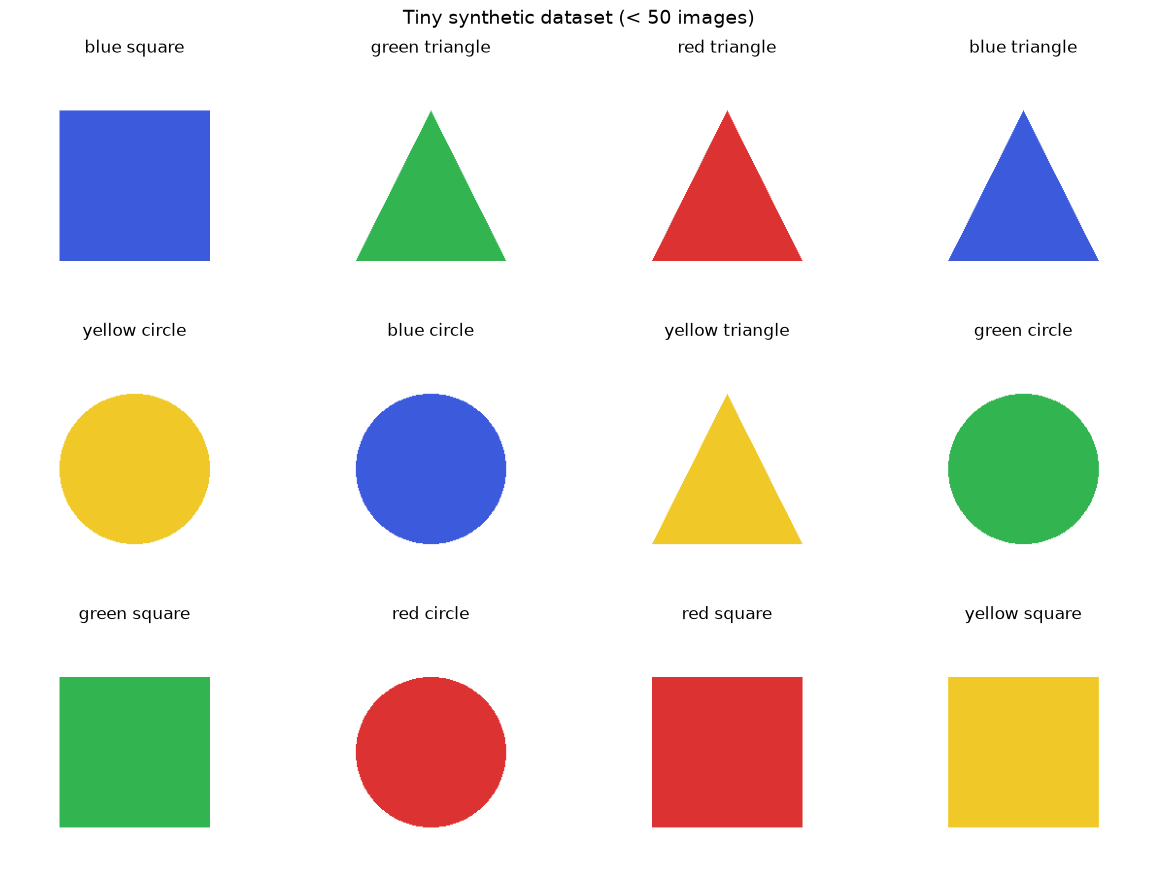

In [5]:
cols = 4
rows = (len(records) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
for ax, rec in zip(axes.flat, records):
    ax.imshow(rec['image'])
    ax.set_title(rec['answer'])
    ax.axis('off')
for ax in axes.flat[len(records):]:
    ax.axis('off')
fig.suptitle('Tiny synthetic dataset (< 50 images)', fontsize=14)
plt.tight_layout()
plt.show()

Format each `(image, question, answer)` triple into an LFM2-VL chat conversation (a `user` turn with the image + question, and an `assistant` turn with the answer).

In [6]:
def to_conversation(record):
    return {
        'messages': [
            {'role': 'user', 'content': [
                {'type': 'image', 'image': record['image']},
                {'type': 'text', 'text': record['question']},
            ]},
            {'role': 'assistant', 'content': [{'type': 'text', 'text': record['answer']}]},
        ]
    }


train_dataset = [to_conversation(r) for r in records]

## 4. Inference helper

A small helper that asks the model the question for a single image.

In [7]:
@torch.no_grad()
def predict(model, image, question=QUESTION, max_new_tokens=16):
    conversation = [{'role': 'user', 'content': [
        {'type': 'image', 'image': image},
        {'type': 'text', 'text': question},
    ]}]
    inputs = processor.apply_chat_template(
        conversation, add_generation_prompt=True, tokenize=True,
        return_dict=True, return_tensors='pt',
    ).to(model.device)
    out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    return processor.decode(out[0, inputs['input_ids'].shape[1]:], skip_special_tokens=True).strip()

## 5. Baseline predictions (before fine-tuning)

Record what the pretrained model answers *before* any training.

In [8]:
model.eval()
before_preds = [predict(model, rec['image']) for rec in records]
for rec, pred in zip(records, before_preds):
    print(f"target={rec['answer']:<16} before={pred!r}")

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


target=blue square      before='blue'
target=green triangle   before='green <triangle>'
target=red triangle     before='red <triangle>'
target=blue triangle    before='blue <shape> triangle'
target=yellow circle    before='yellow circle'
target=blue circle      before='The image contains a blue circle.'
target=yellow triangle  before='yellow triangle'
target=green circle     before='green circle'
target=green square     before='green'
target=red circle       before='The image contains a red circle.'
target=red square       before='The image contains a red square.'
target=yellow square    before='yellow'


## 6. LoRA fine-tuning with TRL `SFTTrainer`

We attach LoRA adapters to the attention projections and the MLP, and train with TRL's `SFTTrainer`. A tiny `TrainerCallback` records the loss (and token accuracy) at every step so we can plot the curve afterwards.

The collator tokenizes a batch with the chat template and builds `labels`, masking **pad tokens** and the **`<image>` placeholder tokens** so the loss is only computed on real text.

In [9]:
from peft import LoraConfig
from transformers import TrainerCallback
from trl import SFTConfig, SFTTrainer

peft_config = LoraConfig(
    r=8, lora_alpha=16, lora_dropout=0.05, bias='none',
    target_modules=['q_proj', 'k_proj', 'v_proj', 'out_proj', 'gate_proj', 'up_proj', 'down_proj'],
    task_type='CAUSAL_LM',
)

pad_token_id = processor.tokenizer.pad_token_id
image_token_id = processor.image_token_id


def collate_fn(examples):
    batch = processor.apply_chat_template(
        [ex['messages'] for ex in examples],
        add_generation_prompt=False, tokenize=True,
        return_dict=True, return_tensors='pt', padding=True,
    )
    labels = batch['input_ids'].clone()
    labels[labels == pad_token_id] = -100
    labels[labels == image_token_id] = -100
    batch['labels'] = labels
    return batch


class LossHistory(TrainerCallback):
    def __init__(self):
        self.steps, self.loss, self.acc = [], [], []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and 'loss' in logs:
            self.steps.append(state.global_step)
            self.loss.append(logs['loss'])
            self.acc.append(logs.get('mean_token_accuracy'))


history = LossHistory()

In [10]:
sft_config = SFTConfig(
    output_dir='./lfm2-vl-450m-lora',
    num_train_epochs=6,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=1,
    learning_rate=1e-4,
    max_length=1024,
    logging_steps=1,
    bf16=torch.cuda.is_available(),
    report_to='none',
    seed=SEED,
    remove_unused_columns=False,
    dataset_kwargs={'skip_prepare_dataset': True},
)

trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=train_dataset,
    data_collator=collate_fn,
    peft_config=peft_config,
    processing_class=processor.tokenizer,
    callbacks=[history],
)

trainer.train()

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 7, 'bos_token_id': 1, 'pad_token_id': 0}.


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


Step,Training Loss
1,7.698948
2,7.705638
3,7.395198
4,7.203386
5,7.093263
6,6.957486
7,6.699920
8,6.378435
9,6.321083
10,6.119893


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


...

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


/usr/local/lib/python3.11/dist-packages/peft/utils/save_and_load.py:372: UserWarning: Could not find a config file in LiquidAI/LFM2-VL-450M - will assume that the vocabulary was not modified.
  warnings.warn(


TrainOutput(global_step=72, training_loss=4.406784501340654, metrics={'train_runtime': 247.2479, 'train_samples_per_second': 0.291, 'train_steps_per_second': 0.291, 'total_flos': 15992288040960.0, 'train_loss': 4.406784501340654})

## 7. Visualize the training loss

The loss should fall steadily while token accuracy climbs toward 1.0.

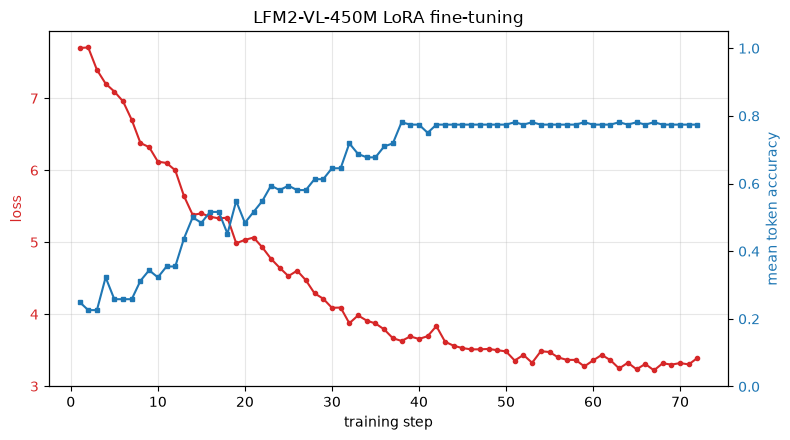

In [11]:
fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.plot(history.steps, history.loss, color='tab:red', marker='o', ms=3, label='loss')
ax1.set_xlabel('training step')
ax1.set_ylabel('loss', color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')
ax1.grid(alpha=0.3)

if any(a is not None for a in history.acc):
    ax2 = ax1.twinx()
    ax2.plot(history.steps, history.acc, color='tab:blue', marker='s', ms=3, label='token accuracy')
    ax2.set_ylabel('mean token accuracy', color='tab:blue')
    ax2.tick_params(axis='y', labelcolor='tab:blue')
    ax2.set_ylim(0, 1.05)

plt.title('LFM2-VL-450M LoRA fine-tuning')
fig.tight_layout()
plt.show()

## 8. Predictions after fine-tuning

In [12]:
trainer.model.eval()
after_preds = [predict(trainer.model, rec['image']) for rec in records]
for rec, pred in zip(records, after_preds):
    print(f"target={rec['answer']:<16} after={pred!r}")

target=blue square      after='blue square'
target=green triangle   after='green triangle'
target=red triangle     after='red triangle'
target=blue triangle    after='blue triangle'
target=yellow circle    after='yellow circle'
target=blue circle      after='blue circle'
target=yellow triangle  after='yellow triangle'
target=green circle     after='green circle'
target=green square     after='green square'
target=red circle       after='red circle'
target=red square       after='red square'
target=yellow square    after='yellow square'


## 9. Before vs. after — visual comparison

Each image is annotated with its target answer and the model's prediction **before** (red if wrong) and **after** (green if correct) fine-tuning.

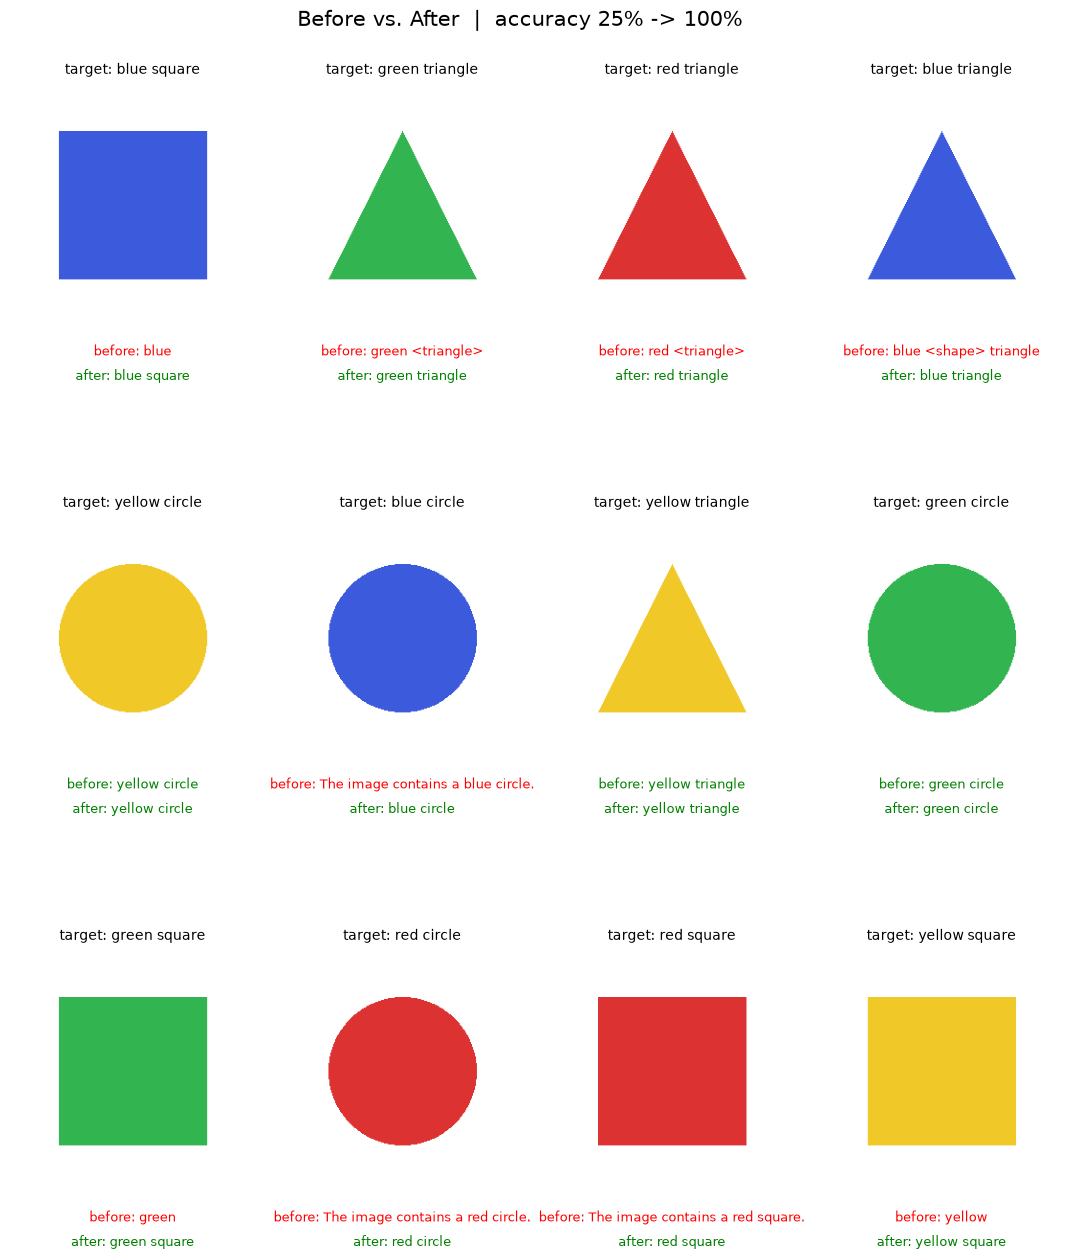

In [13]:
def is_correct(pred, target):
    return pred.strip().lower().startswith(target.lower())


cols = 4
rows = (len(records) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(3.4 * cols, 4.6 * rows))
for ax, rec, before, after in zip(axes.flat, records, before_preds, after_preds):
    ax.imshow(rec['image'])
    ax.axis('off')
    b_color = 'green' if is_correct(before, rec['answer']) else 'red'
    a_color = 'green' if is_correct(after, rec['answer']) else 'red'
    ax.set_title(f"target: {rec['answer']}", fontsize=10)
    ax.text(0.5, -0.07, f'before: {before}', color=b_color, fontsize=9,
            ha='center', va='top', wrap=True, transform=ax.transAxes)
    ax.text(0.5, -0.17, f'after: {after}', color=a_color, fontsize=9,
            ha='center', va='top', wrap=True, transform=ax.transAxes)
for ax in axes.flat[len(records):]:
    ax.axis('off')

before_acc = sum(is_correct(p, r['answer']) for p, r in zip(before_preds, records)) / len(records)
after_acc = sum(is_correct(p, r['answer']) for p, r in zip(after_preds, records)) / len(records)
fig.suptitle(f'Before vs. After  |  accuracy {before_acc:.0%} -> {after_acc:.0%}', fontsize=15)
plt.subplots_adjust(hspace=0.55, wspace=0.1, top=0.94)
plt.show()

## 10. Save and reload the adapter

The LoRA adapter is only a few MB. Save it alongside the processor, then reload on top of the base model.

In [14]:
trainer.save_model('./lfm2-vl-450m-lora')
processor.save_pretrained('./lfm2-vl-450m-lora')

# Reload later with:
# from peft import PeftModel
# base = AutoModelForImageTextToText.from_pretrained(model_id, dtype=dtype)
# tuned = PeftModel.from_pretrained(base, './lfm2-vl-450m-lora')
# tuned = tuned.merge_and_unload()  # optional: fold LoRA into the base weights
print('Saved adapter + processor to ./lfm2-vl-450m-lora')

Saved adapter + processor to ./lfm2-vl-450m-lora


/usr/local/lib/python3.11/dist-packages/peft/utils/save_and_load.py:372: UserWarning: Could not find a config file in LiquidAI/LFM2-VL-450M - will assume that the vocabulary was not modified.
  warnings.warn(


## Next steps

- Swap the synthetic data for your own images — keep the `{image, question, answer}` shape and everything else works unchanged.
- To fine-tune on a real Hub dataset (e.g. [`HuggingFaceH4/llava-instruct-mix-vsft`](https://huggingface.co/datasets/HuggingFaceH4/llava-instruct-mix-vsft)), load a small slice with `datasets.load_dataset(name, split='train[:40]')` and map it into the same conversation format.
- On a GPU you can raise `MAX_SAMPLES`, the number of epochs, and the image-token budget for stronger results.

**References**: [Liquid AI blog](https://www.liquid.ai/blog/lfm2-vl-efficient-vision-language-models) · [LFM2-VL-450M model card](https://huggingface.co/LiquidAI/LFM2-VL-450M) · [LFM2-VL TRL guide](https://docs.liquid.ai/customization/finetuning-frameworks/trl)